# ==== Run on Google Colab ======

## import data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor, early_stopping
import time
import warnings
warnings.filterwarnings("ignore")
# Load data
df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Hackathon_Data2025.csv')
df1['log_date'] = pd.to_datetime(df1['log_date'])
df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Hackathon_Data2024.csv')
df2['log_date'] = pd.to_datetime(df2['log_date'])
df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Hackathon_Data2023.csv')
df3['log_date'] = pd.to_datetime(df3['log_date'])
asin_dim = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Hackathon_Data_DIMASIN.csv')
asin_dim = asin_dim[['asin_y4a', 'master_category', 'super_category', 'main_category', 'category', 'product_line']].drop_duplicates()
# Union all
data = pd.concat([df1, df2, df3], ignore_index=True)
data.drop(columns=['comp_rank','inv_incoming','inv_available','Unnamed: 0'],inplace=True)
data['log_date'] = pd.to_datetime(data['log_date'])
df_asin_root = data[['log_date', 'asin_y4a', 'country', 'platform', 'y4a_nmv','y4a_unitsold', 'y4a_asp']].drop_duplicates()
print(len(data))

1734783


In [4]:
df_direct = data[data['comp_label']=='Direct'][['log_date', 'asin_y4a','y4a_rank', 'y4a_market_share','asin_competitor', 'comp_nmv', 'comp_unitsold', 'comp_asp', 'comp_market_share', 'asp_y4a_comp_pct','cm_external']]
df_direct = df_direct.rename(
    columns={col: f'direct_{col}' for col in df_direct.columns if col not in ['log_date', 'asin_y4a']}
)

df_port = data[data['comp_label']=='Portfolio'][['log_date', 'asin_y4a','y4a_rank', 'y4a_market_share','asin_competitor', 'comp_nmv', 'comp_unitsold', 'comp_asp', 'comp_market_share', 'asp_y4a_comp_pct', 'cm_external']]
df_port = df_port.rename(
    columns={col: f'port_{col}' for col in df_port.columns if col not in ['log_date', 'asin_y4a']}
)
df = pd.merge(df_asin_root, df_direct,on=['log_date', 'asin_y4a'], how='left')
df = pd.merge(df, df_port,on=['log_date', 'asin_y4a'], how='left')
df = pd.merge(df, asin_dim, on='asin_y4a', how='inner')
df.head()

,log_date,asin_y4a,country,platform,y4a_nmv,y4a_unitsold,y4a_asp,direct_y4a_rank,direct_y4a_market_share,direct_asin_competitor,...,port_comp_unitsold,port_comp_asp,port_comp_market_share,port_asp_y4a_comp_pct,port_cm_external,master_category,super_category,main_category,category,product_line
0,2025-01-04,B005MHDPBW,USA,Amazon,244.0,5.0,48.8,2.0,45.61,B0CMXXZV5R,...,238.0,378.43,24.08,12.90,9.967601,Indoor Equipment,Strength Training,Upper body exercises,Dumbbells,Adjustable Dumbbells
1,2025-01-05,B005MHDPBW,USA,Amazon,99.0,2.0,49.5,2.0,34.38,B0CMXXZV5R,...,544.0,378.00,38.06,13.10,19.935201,Indoor Equipment,Strength Training,Upper body exercises,Dumbbells,Adjustable Dumbbells
2,2025-01-06,B005MHDPBW,USA,Amazon,60.0,1.0,60.0,2.0,25.00,B0CMXXZV5R,...,476.0,378.18,40.32,15.87,0.000000,Indoor Equipment,Strength Training,Upper body exercises,Dumbbells,Adjustable Dumbbells
3,2025-01-07,B005MHDPBW,USA,Amazon,64.0,1.0,64.0,2.0,42.38,B0CMXXZV5R,...,424.0,378.02,43.96,16.93,0.000000,Indoor Equipment,Strength Training,Upper body exercises,Dumbbells,Adjustable Dumbbells
4,2025-01-08,B005MHDPBW,USA,Amazon,60.0,1.0,60.0,2.0,29.13,B0CMXXZV5R,...,296.0,399.51,35.62,15.02,9.967601,Indoor Equipment,Strength Training,Upper body exercises,Dumbbells,Adjustable Dumbbells


## ML/AI

### Transform data

In [5]:
# 1. recalcu y4a_asp from NMV và Unitsold
mask_recalc = df['y4a_asp'].isna() & (df['y4a_unitsold'] > 0) & (df['y4a_nmv'].notna())
df.loc[mask_recalc, 'y4a_asp'] = df.loc[mask_recalc, 'y4a_nmv'] / df.loc[mask_recalc, 'y4a_unitsold']
print(f"Đã tính toán lại {mask_recalc.sum()} giá trị y4a_asp.")

# 2. remove row missing: y4a_asp (or Unitsold=0)
df.dropna(subset=['y4a_asp'], inplace=True)
df = df[df['y4a_unitsold'] > 0].copy()

print(f"Kích thước sau khi clean y4a_asp và Unitsold=0: {len(df)}")

Đã tính toán lại 0 giá trị y4a_asp.
Kích thước sau khi clean y4a_asp và Unitsold=0: 416791


In [6]:
# 1. Define group columns
rank_cols = ['direct_y4a_rank', 'port_y4a_rank']
share_value_cols = [
    'direct_y4a_market_share', 'direct_comp_nmv', 'direct_comp_unitsold',
    'direct_comp_market_share', 'port_y4a_market_share', 'port_comp_nmv',
    'port_comp_unitsold', 'port_comp_market_share'
]
asp_pct_cm_cols = [
    'direct_comp_asp', 'port_comp_asp', 'direct_asp_y4a_comp_pct',
    'port_asp_y4a_comp_pct', 'direct_cm_external', 'port_cm_external'
]
competitor_asin_cols = ['direct_asin_competitor', 'port_asin_competitor']

# 2. Imputation
# -999: a special value for LGBM
df[rank_cols + asp_pct_cm_cols] = df[rank_cols + asp_pct_cm_cols].fillna(-999)
df[share_value_cols] = df[share_value_cols].fillna(0)
df[competitor_asin_cols] = df[competitor_asin_cols].fillna('NO_COMPETITOR')

# log-transformed
df['target_unitsold'] = np.log1p(df['y4a_unitsold'])
categorical_features = [
    'asin_y4a', 'country', 'platform', 'direct_asin_competitor', 'port_asin_competitor',
    'master_category', 'super_category', 'main_category', 'category', 'product_line'
]
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype(str).astype('category')

In [7]:
def create_time_features(df):
    df['year'] = df['log_date'].dt.year
    df['month'] = df['log_date'].dt.month
    df['day'] = df['log_date'].dt.day
    df['weekday'] = df['log_date'].dt.weekday
    df['dayofyear'] = df['log_date'].dt.dayofyear
    df['is_weekend'] = (df['log_date'].dt.weekday >= 5).astype('category')
    big_sale_ranges = [
        pd.date_range('2023-10-10', '2023-10-11'),
        pd.date_range('2022-10-11', '2022-10-12'),
        pd.date_range('2023-07-11', '2023-07-12'),
        pd.date_range('2024-07-16', '2024-07-17'),
        pd.date_range('2024-10-08', '2024-10-09'),
        pd.date_range('2025-07-08', '2025-07-11'),
        pd.date_range('2025-10-07', '2025-10-08')
    ]
    df['is_big_sale'] = df['log_date'].apply(lambda x: any(x in r for r in big_sale_ranges)).astype('category')
    return df

df = create_time_features(df.copy())
def create_lagged_features(df, lag_days=[1, 3, 7]):
    # fort data
    df = df.sort_values(by=['asin_y4a', 'country', 'platform', 'log_date']).reset_index(drop=True)
    lag_cols = ['y4a_asp', 'y4a_unitsold']
    for col in lag_cols:
        for lag in lag_days:
            new_col_name = f'lag_{col}_{lag}d'
            # calcu lag
            df[new_col_name] = df.groupby(['asin_y4a', 'country', 'platform'])[col].shift(lag)
            df[new_col_name] = df[new_col_name].fillna(-999)
    return df

df = create_lagged_features(df.copy())
# Price Gap
df['direct_price_gap'] = df['y4a_asp'] - df['direct_comp_asp']
df['port_price_gap'] = df['y4a_asp'] - df['port_comp_asp']

# update categorical columns
CATEGORICAL_FEATURES = [
    'asin_y4a', 'country', 'platform', 'direct_asin_competitor', 'port_asin_competitor',
    'master_category', 'super_category', 'main_category', 'category', 'product_line',
    'year', 'month', 'day', 'weekday', 'is_weekend','is_big_sale'
]

for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        df[col] = df[col].astype('category')

### Save data history use for predict

In [8]:
df_sorted = df.sort_values(by=['asin_y4a','log_date'], ascending=[True, False])
latest_data_df = df_sorted.groupby('asin_y4a').head(7)
latest_data_df = latest_data_df.reset_index(drop=True)
print(len(df['asin_y4a'].unique().to_list()))
print(len(latest_data_df))
latest_data_df.to_csv("/content/drive/MyDrive/Colab Notebooks/data/model/data_history_for_predict.csv", index=False)

1127
7754


### Train model

In [9]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import time

TARGET_COL = 'target_unitsold'
EXCLUDE_COLS = [
    'log_date', 'y4a_unitsold', #'y4a_nmv',
    'direct_asin_competitor', 'port_asin_competitor'
]
# remove column
remove_cols = ['y4a_nmv', 'direct_price_gap','port_comp_asp','direct_cm_external','direct_asp_y4a_comp_pct','direct_y4a_rank','direct_comp_asp'
,'direct_comp_nmv','port_comp_nmv']
for col in df.columns:
  if col in remove_cols:
    df.drop(columns=col, inplace=True)

FEATURES = [col for col in df.columns if col not in EXCLUDE_COLS and col != TARGET_COL]
CATEGORICAL_FEATURES_LGBM = [col for col in FEATURES if df[col].dtype.name == 'category']
print(FEATURES)
print(CATEGORICAL_FEATURES_LGBM)

# split data train/test
split_date = df['log_date'].quantile(0.7)

train_df = df[df['log_date'] < split_date].copy().reset_index(drop=True)
test_df = df[df['log_date'] >= split_date].copy().reset_index(drop=True)

X_train, y_train = train_df[FEATURES], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURES], test_df[TARGET_COL]

print(f"Total Features: {len(FEATURES)}")
print(f"Categorical Features: {CATEGORICAL_FEATURES_LGBM}")
print("-" * 50)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

early_stopping_callback = early_stopping(stopping_rounds=100, verbose=False)

#Config model LightGBM
lgbm = LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=2500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    n_jobs=-1,
    random_state=42,
    colsample_bytree=0.8,
    subsample=0.8,
    categorical_feature=CATEGORICAL_FEATURES_LGBM,
    boosting_type='gbdt',
)

print("\nBắt đầu Huấn luyện LightGBM...")
start_time = time.time()

lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         eval_metric=["rmse", "mae", "mape"],
         callbacks=[early_stopping_callback]
        )

end_time = time.time()
print(f"Thời gian huấn luyện: {end_time - start_time:.2f} giây")

# Predict on data test
y_pred_log = lgbm.predict(X_test)

# Convert into actual Unitsold
# np.expm1(x) = e^x - 1
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

y_pred[y_pred < 0] = 0

['asin_y4a', 'country', 'platform', 'y4a_asp', 'direct_y4a_market_share', 'direct_comp_unitsold', 'direct_comp_market_share', 'port_y4a_rank', 'port_y4a_market_share', 'port_comp_unitsold', 'port_comp_market_share', 'port_asp_y4a_comp_pct', 'port_cm_external', 'master_category', 'super_category', 'main_category', 'category', 'product_line', 'year', 'month', 'day', 'weekday', 'dayofyear', 'is_weekend', 'is_big_sale', 'lag_y4a_asp_1d', 'lag_y4a_asp_3d', 'lag_y4a_asp_7d', 'lag_y4a_unitsold_1d', 'lag_y4a_unitsold_3d', 'lag_y4a_unitsold_7d', 'port_price_gap']
['asin_y4a', 'country', 'platform', 'master_category', 'super_category', 'main_category', 'category', 'product_line', 'year', 'month', 'day', 'weekday', 'is_weekend', 'is_big_sale']
Total Features: 32
Categorical Features: ['asin_y4a', 'country', 'platform', 'master_category', 'super_category', 'main_category', 'category', 'product_line', 'year', 'month', 'day', 'weekday', 'is_weekend', 'is_big_sale']
----------------------------------

### Value model

In [10]:
# calcu metric
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mape = mean_absolute_percentage_error(y_actual, y_pred) * 100
mae = np.mean(np.abs(y_actual - y_pred))

print("-" * 50)
print("MODEL EVALUATION RESULT ON THE TEST SET")
print("-" * 50)
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print("-" * 50)

--------------------------------------------------
MODEL EVALUATION RESULT ON THE TEST SET
--------------------------------------------------
RMSE (Root Mean Squared Error): 3.8122
MAE (Mean Absolute Error): 0.8318
MAPE (Mean Absolute Percentage Error): 10.28%
--------------------------------------------------


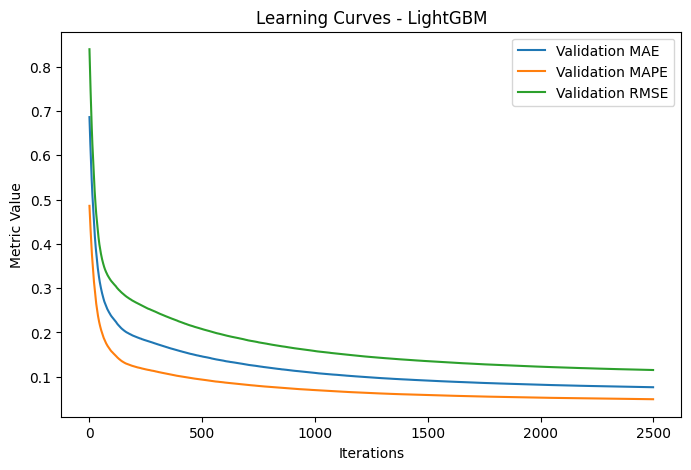

In [11]:
# Variation of the LightBGM Model's Performance Metrics
import matplotlib.pyplot as plt
evals_result = lgbm.evals_result_
plt.figure(figsize=(8,5))
for metric in evals_result['valid_0'].keys():
    plt.plot(evals_result['valid_0'][metric], label=f"Validation {metric.replace('l1','MAE').upper()}")
plt.xlabel("Iterations")
plt.ylabel("Metric Value")
plt.title("Learning Curves - LightGBM")
plt.legend()
plt.show()


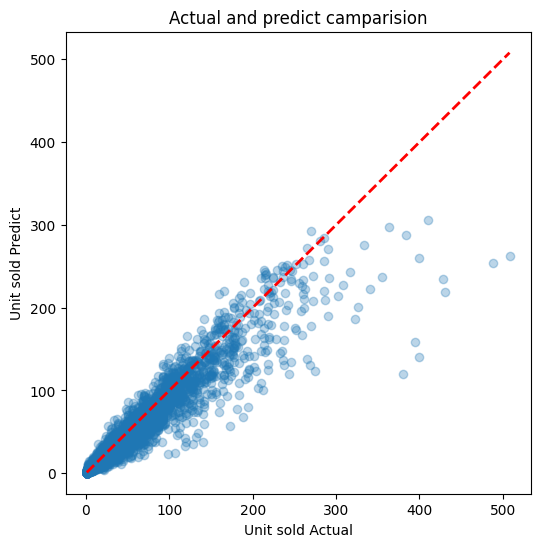

In [12]:
# Actual and predict camparision
plt.figure(figsize=(6,6))
plt.scatter(y_actual, y_pred, alpha=0.3)
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()],
         'r--', lw=2)
plt.xlabel("Unit sold Actual")
plt.ylabel("Unit sold Predict")
plt.title("Actual and predict camparision")
plt.show()


## Use model file PKL

In [13]:
import joblib
MODEL_FILENAME = 'lgbm_unitsold_model.pkl'
FEATURES_FILENAME = 'model_features.pkl'
path_pkl ='/content/drive/MyDrive/Colab Notebooks/data/model/'
# Save model
joblib.dump(lgbm,path_pkl+ MODEL_FILENAME)
print(f"Save model successfull, path: {path_pkl+MODEL_FILENAME}")
#
joblib.dump(FEATURES, path_pkl+FEATURES_FILENAME)
print(f"List Features: {path_pkl+FEATURES_FILENAME}")


Save model successfull, path: /content/drive/MyDrive/Colab Notebooks/data/model/lgbm_unitsold_model.pkl
List Features: /content/drive/MyDrive/Colab Notebooks/data/model/model_features.pkl


### Predict new data

In [14]:
# import joblib
# import pandas as pd
# import numpy as np
# import warnings
# warnings.filterwarnings("ignore")

MODEL_FILENAME = 'lgbm_unitsold_model.pkl'
FEATURES_FILENAME = 'model_features.pkl'
# Load model and features
lgbm = joblib.load(path_pkl+MODEL_FILENAME)
FEATURES = joblib.load(path_pkl+FEATURES_FILENAME)
historical_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/model/data_history_for_predict.csv')

historical_df['log_date'] = pd.to_datetime(historical_df['log_date'])

def predict_unitsold(date, asin_y4a, asp):
    """
    Predict unitsold for a ASIN, day and price ASP.

    Args:
        date (str or datetime): (YYYY-MM-DD).
        asin_y4a (str): ASIN.
        asp (float): price ASP.

    Returns:
        float: unitsold predict.
    """
    date = pd.to_datetime(date)

    # Create DataFrame get data from historical data
    # Get basic infomation of ASIN from history data
    # Find last row of ASIN/Country/Platform sort by date (day < day_predict)
    last_day_data = historical_df[
        (historical_df['asin_y4a'] == asin_y4a) &
        (historical_df['log_date'] < date)
    ].sort_values(by='log_date', ascending=False).drop_duplicates(
        subset=['asin_y4a', 'country', 'platform'] # get last row
    )

    if last_day_data.empty:
        print(f"Not found history data of ASIN {asin_y4a} before {date.date()}. Return 0")
        return 0

    # Create DataFrame for predict_date
    # Keep all columns except the lag feature columns and the columns that will be recalculated
    base_cols = [col for col in FEATURES if not col.startswith('lag_') and col not in ['direct_price_gap', 'port_price_gap', 'year', 'month', 'day', 'weekday', 'dayofyear', 'is_weekend', 'y4a_asp']]

    # Take the base data from the last retrieved row
    predict_df = last_day_data[base_cols].copy() # Explicitly create a copy

    # Assign new date and price
    predict_df['log_date'] = date
    predict_df['y4a_asp'] = asp # Assign new ASP value

    # Add time-related features for the prediction date
    predict_df = create_time_features(predict_df.copy()) # Explicitly create a copy

    # Recalculate lagged features
    # Need to combine historical data and prediction date to compute lag correctly
    combined_df = pd.concat([historical_df, predict_df], ignore_index=True)

    # Sort to calculate lag correctly
    combined_df = combined_df.sort_values(by=['asin_y4a', 'country', 'platform', 'log_date']).reset_index(drop=True)

    # Compute lag only for the prediction date (the newly added row)
    # Filter only rows with log_date equal to the prediction date
    predict_df_with_lag = create_lagged_features(combined_df.copy(), lag_days=[1, 3, 7]) # Explicitly create a copy and pass to create_lagged_features
    predict_df = predict_df_with_lag[predict_df_with_lag['log_date'] == date].copy() # Explicitly create a copy

    # Recalculate price gaps
    # Ensure competitor ASP columns are not NaN before calculation
    predict_df['direct_price_gap'] = predict_df['y4a_asp'] - predict_df['direct_comp_asp'].fillna(-999)
    predict_df['port_price_gap'] = predict_df['y4a_asp'] - predict_df['port_comp_asp'].fillna(-999)

    # Apply the same column order as during training
    X_predict = predict_df[FEATURES].copy() # Explicitly create a copy

    # Ensure categorical columns have the same categories as during training
    for col in CATEGORICAL_FEATURES_LGBM:
        if col in X_predict.columns:
            X_predict[col] = X_predict[col].astype('category')
            # May need additional handling for new categories appearing in prediction data
            # that were not present in training data (ignored here for simplicity)

    # print("Data predict: ",X_predict['is_big_sale'])
    # Make prediction (on log-transformed data)
    y_pred_log = lgbm.predict(X_predict)

    # Convert back to actual Unitsold
    y_pred = np.expm1(y_pred_log)

    # Ensure unitsold is not negative
    y_pred[y_pred < 0] = 0

    # Return the first predicted value (since predict_df only has one row for that date)
    return int(y_pred[0])



In [15]:
# # Example usage:
# Predict units sold for ASIN 'B005MHDPBW' on '2025-10-01' with ASP 50.0
price1 = 48
asin = 'B005MHDPBW'
predicted_units = predict_unitsold('2025-10-07', asin, price1)
print(f"\nPredict unitsold for {asin} with prices {price1}: {int(predicted_units)}")

# Predict units sold for ASIN 'B0DSBXVQ4V' on '2025-10-01' with ASP 70.0
price2 = 17
asin2 = 'B0093CMYT6'
predicted_units_2 = predict_unitsold('2025-12-01',asin2, price2)
print(f"Predict unitsold for {asin2}  with prices {price2}: {int(predicted_units_2)}")


Predict unitsold for B005MHDPBW with prices 48: 1
Predict unitsold for B0093CMYT6  with prices 17: 56
